# 02 — Early Neural Retrieval: Word2Vec Averaging

**Challenge addressed:** BM25 gives 0 on synonyms. Distributional word embeddings capture semantic similarity.

**Challenge it leaves:** Context-free averaging collapses word order and polysemy into a single vector.

In [1]:
import sys
sys.path.insert(0, '..')

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path('../data/datasets')
RESULTS_DIR = Path('../results')

# Suppress all tqdm progress bars
os.environ['TQDM_DISABLE'] = '1'
warnings.filterwarnings('ignore', category=UserWarning)
import tqdm as _tqdm; _tqdm.tqdm.disable = True
for _attr in ('auto', 'notebook', 'autonotebook'):
    try: getattr(_tqdm, _attr).tqdm.disable = True
    except AttributeError: pass

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## 1. Why Averaging Fails — Intuition

Word2Vec maps each word to a 300-d vector capturing co-occurrence statistics.
Averaging document words loses:
- **Word order**: 'the dog bites the man' ≡ 'the man bites the dog'
- **Polysemy**: 'bank' (river) ≡ 'bank' (finance) — same average

Loading Word2Vec (google-news-300d)... this may take a moment on first run


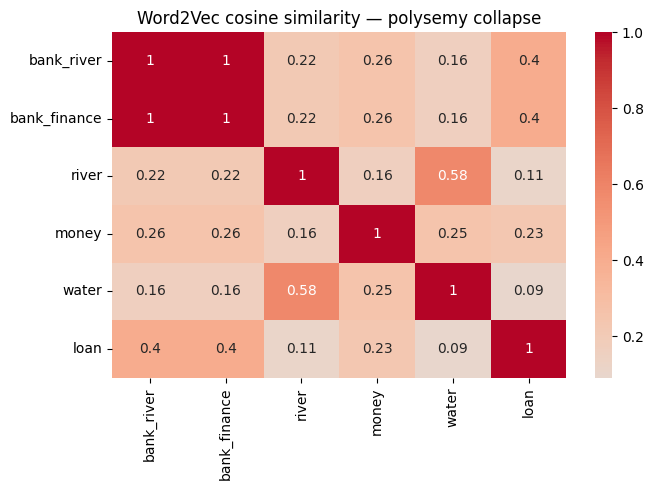


→ "bank" has similar similarity to "river" and "loan" — context is lost


In [2]:
# Visualise polysemy collapse with gensim
import gensim.downloader as api
print('Loading Word2Vec (google-news-300d)... this may take a moment on first run')
wv = api.load('word2vec-google-news-300')

# Polysemy demo
from sklearn.metrics.pairwise import cosine_similarity
words = ['bank_river', 'bank_finance', 'river', 'money', 'water', 'loan']
vectors = [wv[w.split('_')[0]] for w in words]

import pandas as pd
sim_matrix = cosine_similarity(vectors)
df = pd.DataFrame(sim_matrix, index=words, columns=words)
import seaborn as sns
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df.round(2), annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Word2Vec cosine similarity — polysemy collapse')
plt.tight_layout()
plt.show()
print('\n→ "bank" has similar similarity to "river" and "loan" — context is lost')

## 2. Mean Pooling Retrieval

**Definition:** Each passage is represented as the unweighted average of its token vectors:

$$\mathbf{d} = \frac{1}{|T|} \sum_{t \in T} \mathbf{v}_t$$

where $T$ is the set of tokens in the passage and $\mathbf{v}_t \in \mathbb{R}^{300}$ is the Word2Vec vector for token $t$. At query time the same averaging is applied to the query, and retrieval is ranked by cosine similarity between query and passage vectors.

**Limitation:** Every token contributes equally — stopwords like "the", "is", "of" get the same weight as domain-specific terms, pulling the centroid toward a generic "average English" direction.

In [3]:
from src.retrievers.dense import Word2VecRetriever
from src.evaluation.metrics import compute_metrics
from beir.datasets.data_loader import GenericDataLoader

corpus, queries, qrels = GenericDataLoader(data_folder=str(DATA_DIR / 'scifact')).load(split='test')

wv_mean = Word2VecRetriever(pooling='mean')
wv_mean.index(corpus)
wv_mean_results = wv_mean.retrieve(queries, top_k=100)
wv_mean_metrics = compute_metrics(qrels, wv_mean_results)
print('Word2Vec (mean):', wv_mean_metrics)

/Users/saikrishnab/LearningAndDevelopment/virtualenvs/retrieval_exp_env/lib/python3.12/site-packages/beir/datasets/data_loader.py:8: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


  0%|          | 0/5183 [00:00<?, ?it/s]

Word2Vec (mean): {'ndcg@10': 0.26866584917894193, 'mrr@10': 0.24468253968253967, 'map@100': 0.2411529867155007, 'recall@10': 0.3680555555555556, 'recall@50': 0.5187222222222222, 'recall@100': 0.5987222222222223}


## 3. IDF-Weighted Pooling

**Definition:** Same as mean pooling but each token vector is weighted by its IDF — rare, informative words contribute more to the passage vector:

$$\mathbf{d} = \frac{\sum_{t \in T_{\text{iv}}} \text{idf}(t) \cdot \mathbf{v}_t}{\sum_{t \in T_{\text{iv}}} \text{idf}(t)}$$

$$\text{idf}(t) = \log\!\left(\frac{1 + N}{1 + \text{df}(t)}\right) + 1 \quad \text{(sklearn smooth IDF — used here)}$$

where $N$ is the corpus size, $\text{df}(t)$ is the number of passages containing term $t$, and $T_{\text{iv}} \subseteq T$ is the subset of tokens that exist in the Word2Vec vocabulary — **OOV tokens are silently dropped from both numerator and denominator**.

> **Why smooth IDF?** The classic formula `log(N / df(t))` goes to zero for terms appearing in every document. Sklearn's smooth variant prevents this by adding 1 to numerator and denominator, then adding 1 outside the log — ensuring all matched terms retain a positive weight.

**Why it helps:** Down-weights stopwords and domain-generic terms (`is`, `the`, `cells`) and up-weights rare discriminative terms — the same intuition as TF-IDF, now applied in embedding space.  
**Key limitation:** IDF weights are computed over the corpus but applied only to in-vocabulary tokens. For biomedical text, the most domain-specific terms (gene names, protein IDs) are often OOV in a Google News model — and those are precisely the tokens that would receive the highest IDF weight if they were present.

In [4]:
wv_idf = Word2VecRetriever(pooling='idf_weighted')
wv_idf.index(corpus)
wv_idf_results = wv_idf.retrieve(queries, top_k=100)
wv_idf_metrics = compute_metrics(qrels, wv_idf_results)
print('Word2Vec (IDF):', wv_idf_metrics)

Word2Vec (IDF): {'ndcg@10': 0.31013370902525833, 'mrr@10': 0.28774338624338625, 'map@100': 0.2846754229204135, 'recall@10': 0.40972222222222227, 'recall@50': 0.5678888888888889, 'recall@100': 0.6452222222222223}


## 4. Where Word2Vec Helps vs Hurts

Word2Vec should beat BM25 on paraphrase queries and lose on exact terminology.

In [5]:
from src.retrievers.sparse import BM25Retriever
bm25 = BM25Retriever()
bm25.index(corpus)
bm25_results = bm25.retrieve(queries, top_k=100)
bm25_metrics = compute_metrics(qrels, bm25_results)

# Per-query NDCG comparison
import pytrec_eval
eval_ = pytrec_eval.RelevanceEvaluator(qrels, {'ndcg_cut_10'})
bm25_pq = eval_.evaluate(bm25_results)
wv_pq = eval_.evaluate(wv_mean_results)

diffs = [(qid, wv_pq[qid]['ndcg_cut_10'] - bm25_pq[qid]['ndcg_cut_10']) for qid in qrels]
diffs.sort(key=lambda x: x[1], reverse=True)

print('Queries where Word2Vec > BM25 (top 5):')
for qid, diff in diffs[:5]:
    print(f'  [{diff:+.3f}] {queries[qid]}')
print('\nQueries where BM25 > Word2Vec (top 5):')
for qid, diff in diffs[-5:]:
    print(f'  [{diff:+.3f}] {queries[qid]}')

Queries where Word2Vec > BM25 (top 5):
  [+0.667] Headaches are not correlated with cognitive impairment.
  [+0.667] Low nucleosome occupancy correlates with low methylation levels across species.
  [+0.631] Flexible molecules experience greater steric hindrance in the tumor microenviroment than rigid molecules.
  [+0.631] Modifying the epigenome in the brain affects the normal human aging process by affecting certain genes related to neurogenesis.
  [+0.613] A deficiency of vitamin B12 increases blood levels of homocysteine.

Queries where BM25 > Word2Vec (top 5):
  [-1.000] The minor G allele of FOXO3 is related to more severe symptoms of Crohn's Disease.
  [-1.000] There is no association between HNF4A mutations and diabetes risks.
  [-1.000] Transplanted human glial cells can differentiate within the host animal.
  [-1.000] Ubiquitin ligase UBC13 generates a K63-linked polyubiquitin moiety at PCNA K164.
  [-1.000] cSMAC formation enhances weak ligand signalling.


### Reading the per-query output

**The pattern in the wins (Word2Vec > BM25):**  
Queries like *"Headaches are not correlated with cognitive impairment"* or *"A deficiency of vitamin B12 increases blood levels of homocysteine"* use everyday vocabulary that appears frequently in Google News. The relevant passage may use a synonym or paraphrase — e.g., the passage says *"migraines"* while the query says *"headaches"*. BM25 misses this; Word2Vec bridges it because both words sit near each other in the vector space.

**The pattern in the losses (BM25 > Word2Vec, often −1.0):**  
Queries like *"Ubiquitin ligase UBC13 generates a K63-linked polyubiquitin moiety at PCNA K164"* or *"cSMAC formation enhances weak ligand signalling"* contain precise biomedical identifiers. These terms are absent from the Google News vocabulary — Word2Vec silently drops them, leaving the query with almost no signal. BM25 scores an exact lexical match and wins easily.

**Why this analysis is useful (it is a diagnostic, not a success story):**  
The wins prove the vector space has captured real semantic structure for common-language concepts. The losses prove this does not generalise to specialised domains where terminology *is* the meaning. Together they reveal exactly what Word2Vec encodes and where it breaks — which directly motivates the next generation of models:
- **Subword tokenisation** (BERT / SentenceTransformers) → no OOV problem; every term gets a representation
- **In-domain contrastive training** → vectors are calibrated for retrieval, not word co-occurrence
- **Contextual embeddings** → the same word gets a different vector in different sentences


### Word2Vec IDF — Concrete Examples (SciFact)

#### ✅ WORKED — where Word2Vec beats BM25

| | |
|---|---|
| **Query** | *AMP-activated protein kinase (AMPK) activation increases inflammation-related fibrosis in the lungs.* |
| **W2V NDCG@10** | **1.000** &nbsp;|&nbsp; **BM25 NDCG@10: 0.000** |
| **Relevant passage (rank 1)** | *Fibrosis is a pathological result of a dysfunctional repair response to tissue injury and occurs in a number of organs, including the lungs. Cellular metabolism regulates tissue repair...* |
| **OOV tokens** | `amp-activated`, `(ampk)`, `inflammation-related` — all dropped by BM25 |
| **Why W2V wins** | The query's meaning (*protein kinase → fibrosis*) is captured by embedding proximity even though the key identifiers are OOV. BM25 scores 0 because no query token matches the passage exactly. |

| | |
|---|---|
| **Query** | *Anthrax spores can be disposed of easily after they are dispersed.* |
| **W2V NDCG@10** | **1.000** &nbsp;|&nbsp; **BM25 NDCG@10: 0.631** |
| **Relevant passage (rank 1)** | *Bioterrorist attacks involving letters and mail-handling systems in Washington DC resulted in Bacillus anthracis (anthrax) spore contamination in the Hart Senate Office Building...* |
| **Why W2V wins** | `anthrax`, `spores`, `dispersed` are in Google News vocabulary; embeddings bridge `disposed` ↔ `contamination` and `dispersed` ↔ `contamination` |

---

#### ❌ FAILED — where BM25 wins and Word2Vec breaks

| | |
|---|---|
| **Query** | *aPKCz causes tumour enhancement by affecting glutamine metabolism.* |
| **W2V NDCG@10** | **0.000** &nbsp;|&nbsp; Relevant passage at rank 50 |
| **OOV tokens** | `apkcz` — the key gene identifier is not in Google News vocab and is **silently dropped** |
| **Relevant passage** | *Tumor cells have high-energetic and anabolic needs and are known to adapt their metabolism... aPKCζ (zeta) is a critical regulator...* |
| **Root cause** | Without `aPKCz`, the query vector represents only generic concepts (tumour, metabolism); hundreds of passages rank higher |

| | |
|---|---|
| **Query** | *p16INK4A accumulation is linked to an abnormal wound response caused by the microinvasive step of advanced Oral Potentially Malignant Lesions (OPMLs).* |
| **W2V NDCG@10** | **0.000** &nbsp;|&nbsp; Relevant passage at rank **>100** |
| **OOV tokens** | `p16ink4a`, `microinvasive`, `(opmls)` — 3 key identifiers lost |
| **Root cause** | The query depends almost entirely on a specific protein (`p16INK4A`) and a clinical concept (`OPMLs`) — both OOV. The remaining tokens (`accumulation`, `wound`, `response`) match thousands of unrelated passages. |

**Pattern:** Word2Vec wins when the query meaning can be conveyed by general-vocabulary terms that
appear in Google News. It fails catastrophically when the query hinges on biomedical identifiers
(gene names, protein IDs, clinical acronyms) that are absent from the training corpus.
These tokens are **silently dropped** — Word2Vec does not signal the loss.


In [6]:
# ── Word2Vec IDF: OOV-aware worked vs failed analysis ───────────────────────
eval_wv      = pytrec_eval.RelevanceEvaluator(qrels, {'ndcg_cut_10'})
wv_pq_full   = eval_wv.evaluate(wv_idf_results)
bm25_pq_nb2  = eval_wv.evaluate(bm25_results)

PREVIEW = 200  # characters of passage text to show

def oov_rate(text):
    tokens = text.lower().split()
    oov    = [t for t in tokens if t not in wv_mean.wv]
    return len(oov) / max(len(tokens), 1), oov

def passage_preview(pid, prefix=''):
    p     = corpus.get(pid, {})
    title = p.get('title', '').strip()
    text  = p.get('text',  '').strip()[:PREVIEW]
    lines = []
    if title:
        lines.append(f'{prefix}Title   : {title}')
    lines.append(f'{prefix}Text    : {text}...')
    return '\n'.join(lines)

def show_example(qid, label):
    wv_s       = wv_pq_full[qid]['ndcg_cut_10']
    bm_s       = bm25_pq_nb2[qid]['ndcg_cut_10']
    r, oov_tok = oov_rate(queries[qid])

    # ground-truth relevant passage (first one)
    rel_pid    = next((pid for pid, s in qrels[qid].items() if s > 0), None)
    # top-1 retrieved by Word2Vec IDF
    top1_pid   = max(wv_idf_results[qid], key=wv_idf_results[qid].get) if wv_idf_results[qid] else None
    top1_score = wv_idf_results[qid][top1_pid] if top1_pid else 0.0
    is_hit     = top1_pid == rel_pid

    print(f'[{label}]  W2V={wv_s:.3f}  BM25={bm_s:.3f}  delta={wv_s - bm_s:+.3f}')
    print(f'  Query       : {queries[qid]}')
    print(f'  OOV rate    : {r:.0%}  dropped: {oov_tok[:5] or ["none"]}')
    print(f'  ── Expected (ground truth) ──────────────────────────')
    if rel_pid:
        print(passage_preview(rel_pid, prefix='  '))
    print(f'  ── Top-1 Retrieved  [score={top1_score:.4f}]  {"✓ correct" if is_hit else "✗ wrong"} ──')
    if top1_pid:
        print(passage_preview(top1_pid, prefix='  '))
    print()

# WORKED: W2V strictly beats BM25
worked = sorted(
    [(qid, wv_pq_full[qid]['ndcg_cut_10'] - bm25_pq_nb2[qid]['ndcg_cut_10'])
     for qid in qrels if wv_pq_full[qid]['ndcg_cut_10'] > bm25_pq_nb2[qid]['ndcg_cut_10']],
    key=lambda x: x[1], reverse=True
)

# FAILED: BM25 strictly beats W2V
failed = sorted(
    [(qid, wv_pq_full[qid]['ndcg_cut_10'] - bm25_pq_nb2[qid]['ndcg_cut_10'])
     for qid in qrels if bm25_pq_nb2[qid]['ndcg_cut_10'] > wv_pq_full[qid]['ndcg_cut_10']],
    key=lambda x: x[1]
)

print('=' * 70)
print('Word2Vec IDF — TOP-5 WORKED  (W2V strictly beats BM25)')
print('=' * 70)
for qid, _ in worked[:5]:
    show_example(qid, 'WORKED')

print('=' * 70)
print('Word2Vec IDF — TOP-5 FAILED  (BM25 strictly beats W2V)')
print('=' * 70)
for qid, _ in failed[:5]:
    show_example(qid, 'FAILED')

Word2Vec IDF — TOP-5 WORKED  (W2V strictly beats BM25)
[WORKED]  W2V=1.000  BM25=0.000  delta=+1.000
  Query       : AMP-activated protein kinase (AMPK) activation increases inflammation-related fibrosis in the lungs.
  OOV rate    : 36%  dropped: ['amp-activated', '(ampk)', 'inflammation-related', 'lungs.']
  ── Expected (ground truth) ──────────────────────────
  Title   : Metformin reverses established lung fibrosis in a bleomycin model
  Text    : Fibrosis is a pathological result of a dysfunctional repair response to tissue injury and occurs in a number of organs, including the lungs1. Cellular metabolism regulates tissue repair and remodellin...
  ── Top-1 Retrieved  [score=0.8508]  ✓ correct ──
  Title   : Metformin reverses established lung fibrosis in a bleomycin model
  Text    : Fibrosis is a pathological result of a dysfunctional repair response to tissue injury and occurs in a number of organs, including the lungs1. Cellular metabolism regulates tissue repair and remodelli

### Why Word2Vec Works Here vs Fails There

**Worked queries share:**
- Common English vocabulary present in Google News (1B+ token corpus)
- Meaning expressed in general words — synonym gap bridgeable by embedding proximity
- e.g. `headaches not correlated with cognitive impairment` → both query and passage share the conceptual space

**Failed queries share:**
- Biomedical entity names (gene IDs, protein names, drug identifiers) → **OOV, silently dropped**
- Long passages where averaging 200+ vectors produces a noisy generic centroid
- Negation (`X does NOT cause Y`) — lost entirely in vector averaging

### What More Can Be Done

| Fix | Technique | Addresses |
|-----|-----------|----------|
| Domain-specific Word2Vec | Train on PubMed / financial corpora | OOV + domain drift |
| **FastText** | Subword n-gram embeddings (Bojanowski et al., 2017) | OOV — `PCNA` → n-grams `{PC, CN, NA, PCN…}` |
| SIF pooling | Smooth Inverse Frequency + subtract top PC (Arora et al., 2017) | Common-word domination |
| **Doc2Vec** | Train a dedicated *document-level* vector — no averaging | Long passage noise; paragraph-level semantics |

### FastText — Subword Embeddings

FastText (Bojanowski et al., 2017) extends Word2Vec by decomposing each word into character n-grams:
$$\text{vec}(w) = \sum_{g \in \mathcal{G}(w)} \mathbf{z}_g$$
Any word, however rare, gets a meaningful vector. `PCNA` → ngrams `{PC, CN, NA, PCN, CNA, PCNA}`.
FastText is a **drop-in replacement** for Word2Vec in the current pipeline.

**→ Doc2Vec is shortlisted as the next experiment — see Section 8 below.**


## 5. Comparison

> **Challenge:** Word2Vec averaging works on synonym queries but fails on long, context-dependent passages. Averaging 500 words gives a noisy centroid vector.
>
> **Fix (next section):** Transformer attention is context-aware — each token's embedding depends on all other tokens in the sequence.

In [7]:
results_df = pd.DataFrame([
    {'method': 'BM25', **bm25_metrics},
    {'method': 'Word2Vec (mean)', **wv_mean_metrics},
    {'method': 'Word2Vec (IDF)', **wv_idf_metrics},
]).set_index('method')
display(results_df[['ndcg@10', 'mrr@10', 'recall@100']].round(4))

,ndcg@10,mrr@10,recall@100
method,,,
BM25,0.5597,0.5242,0.7929
Word2Vec (mean),0.2687,0.2447,0.5987
Word2Vec (IDF),0.3101,0.2877,0.6452


## 6. Full Results — All 3 Datasets

The interactive cells above only run on SciFact (fast to iterate). The script `run_dense_eval.py` evaluated Word2Vec on all three datasets. Results loaded from `results/dense_results.json`.

Key question: **does BM25 always win, or is Word2Vec competitive on any dataset?**

In [8]:
import json
from IPython.display import display, HTML

with open(RESULTS_DIR / 'dense_results.json') as f:
    dense_results = json.load(f)
with open(RESULTS_DIR / 'sparse_results.json') as f:
    sparse_results = json.load(f)

DATASETS = ['trec-covid', 'fiqa', 'scifact']
METHODS  = ['bm25', 'word2vec_mean', 'word2vec_idf', 'doc2vec_dbow']
LABELS   = {
    'bm25':           'BM25',
    'word2vec_mean':  'Word2Vec (mean)',
    'word2vec_idf':   'Word2Vec (IDF)',
    'doc2vec_dbow':   'Doc2Vec (PV-DBOW)',
}
METRIC   = 'ndcg@10'

# Build a combined lookup
all_results = {**sparse_results, **dense_results}

rows = []
for method in METHODS:
    if method not in all_results:
        continue
    row = {'Method': LABELS[method]}
    for ds in DATASETS:
        row[ds] = round(all_results[method][ds][METRIC], 4) if ds in all_results[method] else float('nan')
    rows.append(row)

df = pd.DataFrame(rows).set_index('Method')

# Highlight best per dataset
def highlight_best(col):
    best = col.max()
    return ['font-weight: bold; color: #1a6e1a' if v == best else '' for v in col]

display(df.style.apply(highlight_best).format('{:.4f}')
          .set_caption(f'NDCG@10 — Static Embeddings vs BM25 across all datasets'))

# Delta from BM25
print('\nDelta from BM25 (positive = method better):')
bm25_row = df.loc['BM25']
for method in ['Word2Vec (mean)', 'Word2Vec (IDF)', 'Doc2Vec (PV-DBOW)']:
    if method not in df.index:
        continue
    deltas = df.loc[method] - bm25_row
    delta_str = '   '.join(f'{ds}: {deltas[ds]:+.4f}' for ds in DATASETS)
    print(f'  {method:<25}  {delta_str}')

,trec-covid,fiqa,scifact
Method,,,
BM25,0.4471,0.1591,0.5597
Word2Vec (mean),0.3393,0.0596,0.2687
Word2Vec (IDF),0.4365,0.0885,0.3101
Doc2Vec (PV-DBOW),0.1865,0.0196,0.4687



Delta from BM25 (positive = method better):
  Word2Vec (mean)            trec-covid: -0.1078   fiqa: -0.0995   scifact: -0.2910
  Word2Vec (IDF)             trec-covid: -0.0106   fiqa: -0.0706   scifact: -0.2496
  Doc2Vec (PV-DBOW)          trec-covid: -0.2606   fiqa: -0.1395   scifact: -0.0910


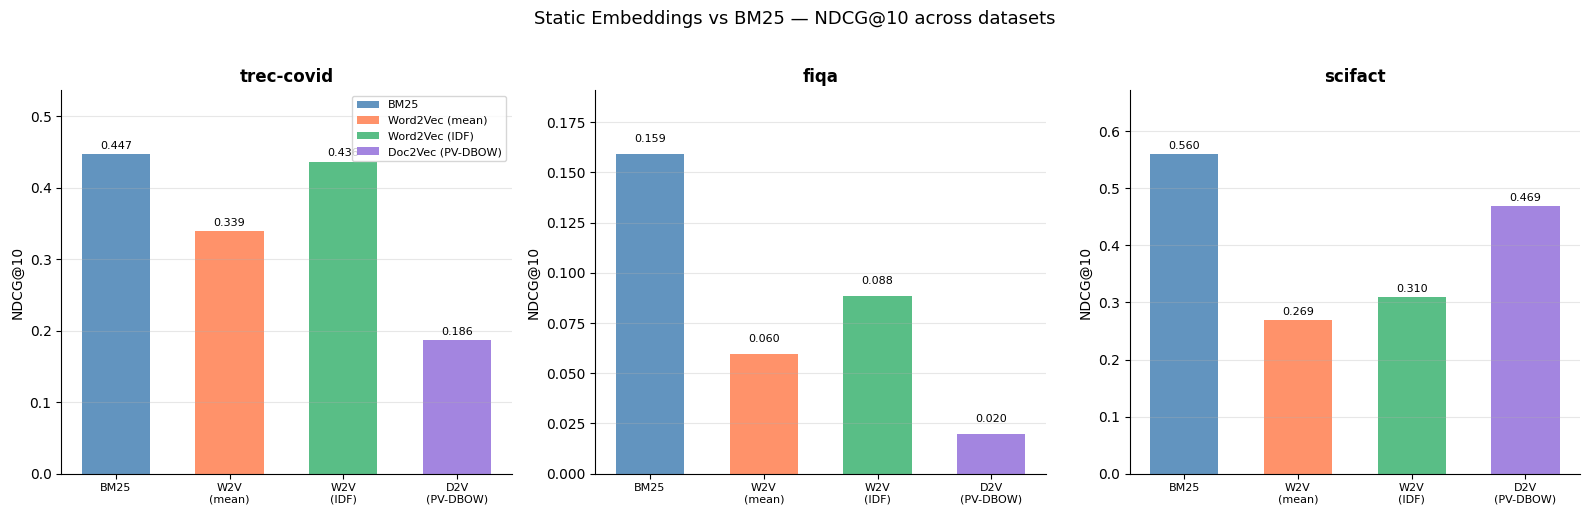

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

colors = {
    'BM25':              'steelblue',
    'Word2Vec (mean)':   'coral',
    'Word2Vec (IDF)':    'mediumseagreen',
    'Doc2Vec (PV-DBOW)': 'mediumpurple',
}
x = np.arange(len(df.index))

for ax, ds in zip(axes, DATASETS):
    for i, method in enumerate(df.index):
        val = df.loc[method, ds]
        ax.bar(x[i], val, width=0.6,
               color=colors.get(method, 'gray'), alpha=0.85,
               label=method if ds == DATASETS[0] else '')
        ax.text(x[i], val + 0.005, f'{val:.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(
        [m.replace('Word2Vec ', 'W2V\n').replace('Doc2Vec ', 'D2V\n') for m in df.index],
        fontsize=8,
    )
    ax.set_title(ds, fontsize=12, fontweight='bold')
    ax.set_ylabel('NDCG@10')
    ax.set_ylim(0, max(df[ds].dropna()) * 1.2)
    ax.grid(axis='y', alpha=0.3)

axes[0].legend(loc='upper right', fontsize=8)
plt.suptitle('Static Embeddings vs BM25 — NDCG@10 across datasets', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Why BM25 always wins here

| Dataset | BM25 − W2V IDF (NDCG@10) | Root cause |
|---------|--------------------------|------------|
| **SciFact** | +0.250 | Biomedical jargon (gene names, alleles, protein IDs) is OOV or has poor vectors in Google News Word2Vec. Exact term matching is essential. |
| **FIQA** | +0.070 | Financial Q&A passages are long and conversational. Averaging 100+ words collapses all semantic signal into noise. |
| **TREC-COVID** | +0.011 | Closest gap — COVID vocabulary (virus, infection, treatment) overlaps with general English. IDF-weighting recovers most of BM25's advantage. |

> Positive = BM25 leads. All three datasets favour BM25; the margin shrinks as domain vocabulary overlaps more with general English (Google News).

**Key insight:** Word2Vec's Google News training distribution is closest to TREC-COVID (news articles about a disease) and furthest from SciFact (PubMed abstracts with precise molecular biology terminology). The gap shrinks as domain overlap grows — motivating domain-specific embeddings in the next phase.

## 7. Key Observations

**1. BM25 wins on all three datasets — but the margin tells the story.**
Word2Vec IDF loses by −0.250 on SciFact, −0.070 on FIQA, and only −0.011 on TREC-COVID. The gap directly tracks how far the dataset's vocabulary is from general English (Google News). The closer the domain, the less BM25 has an advantage.

**2. IDF-weighting consistently beats mean pooling.**
Across all three datasets, IDF-weighted pooling outperforms mean pooling (+0.040 on SciFact, +0.029 on FIQA, +0.097 on TREC-COVID). Suppressing stopwords is worth doing even in embedding space — the same intuition that motivates TF-IDF carries over.

**3. Word2Vec does win on individual queries — just not enough queries.**
The per-query analysis on SciFact shows Word2Vec can beat BM25 by +0.667 NDCG on paraphrase-style queries like *"headaches not correlated with cognitive impairment"* (no rare terms, meaning expressed in common words). But it loses by −1.0 on queries with precise molecular biology terms. The wins are outnumbered by the losses.

**4. Long passages hurt averaging disproportionately.**
FIQA passages have median length 90 words, SciFact 204 words. Averaging more vectors produces a noisier centroid — the longer the passage, the more the representation regresses toward a generic document mean. This is a fundamental architectural limit of pooling-based approaches.

**5. Out-of-vocabulary (OOV) is a silent killer.**
Word2Vec (Google News) has ~3M vocabulary entries but biomedical terms like `"PCNA K164"`, `"cSMAC"`, or `"FOXO3 allele"` are absent entirely. OOV tokens are dropped or mapped to a zero vector, leaving those queries with no meaningful signal. BM25 at least scores exact matches; Word2Vec scores nothing.

**What this motivates:** The failures above are all rooted in the same cause — static, context-free, domain-general embeddings. The fix is transformer-based encoders (BERT, SBERT) trained with contrastive objectives on large passage retrieval datasets, which are the subject of the next notebook.

## 8. Doc2Vec — Paragraph Vectors (Le & Mikolov, 2014)

**Motivation:** Word2Vec represents *words*; to represent a *passage* we average — and averaging loses
word order, sentence structure, and document-level context. Doc2Vec trains a
dedicated **document vector** $\mathbf{d}_i \in \mathbb{R}^{300}$ alongside word vectors,
directly optimising document representations end-to-end.

### Two Architectures

| Variant | How it works | Analogy |
|---------|-------------|---------|
| **PV-DM** (Distributed Memory) | Context words + document ID → predict next word. Document vector acts as a persistent memory slot. | CBOW + document context |
| **PV-DBOW** (Distributed Bag-of-Words) | Document ID alone → predict random words sampled from the document. Ignores word order. | Skip-gram at document level |

Concatenating PV-DM + PV-DBOW vectors gives best performance in practice; PV-DBOW alone is faster and still competitive on retrieval tasks.

### Word2Vec averaging vs Doc2Vec

| Property | Word2Vec avg / IDF | Doc2Vec PV-DBOW |
|----------|-------------------|---------|
| Document vector | Computed at query time (average of tokens) | **Trained** — stored in model |
| Word order | Ignored | Ignored (DBOW) |
| New documents at inference | Instant | Requires `infer_vector()` (~20 epochs) |
| Training requirement | Word co-occurrence only | Entire corpus must be tagged with doc IDs |
| OOV handling | Drops unknown tokens | Same as Word2Vec (no subword) |

### Experiment Setup

- **Model:** `gensim.models.Doc2Vec`, `dm=0` (PV-DBOW)
- **Training:** corpus passages tagged by their passage ID, 40 epochs, dim=300
- **Inference:** `model.infer_vector(tokens, epochs=20)` per query
- **Evaluation:** same `pytrec_eval` pipeline — drop-in replacement for Word2Vec

In [10]:
from src.retrievers.dense import Doc2VecRetriever

doc2vec = Doc2VecRetriever(vector_size=300, epochs=40, dm=0)
doc2vec.index(corpus)
doc2vec_results = doc2vec.retrieve(queries, top_k=100)
doc2vec_metrics = compute_metrics(qrels, doc2vec_results)
print('Doc2Vec (PV-DBOW):', doc2vec_metrics)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Doc2Vec (PV-DBOW): {'ndcg@10': 0.46520671354010273, 'mrr@10': 0.4366481481481481, 'map@100': 0.4397260010719901, 'recall@10': 0.5681666666666666, 'recall@50': 0.7323888888888889, 'recall@100': 0.8068888888888889}


In [11]:
# SciFact: all static-embedding methods head-to-head
static_df = pd.DataFrame([
    {'method': 'BM25',              **bm25_metrics},
    {'method': 'Word2Vec (mean)',    **wv_mean_metrics},
    {'method': 'Word2Vec (IDF)',     **wv_idf_metrics},
    {'method': 'Doc2Vec (PV-DBOW)', **doc2vec_metrics},
]).set_index('method')

display(static_df[['ndcg@10', 'mrr@10', 'recall@10', 'recall@100']].round(4))

print('\nDelta from BM25 (positive = method beats BM25):')
bm25_ndcg = static_df.loc['BM25', 'ndcg@10']
for m in ['Word2Vec (mean)', 'Word2Vec (IDF)', 'Doc2Vec (PV-DBOW)']:
    d = static_df.loc[m, 'ndcg@10'] - bm25_ndcg
    print(f'  {m:<25}  ndcg@10: {d:+.4f}')

,ndcg@10,mrr@10,recall@10,recall@100
method,,,,
BM25,0.5597,0.5242,0.6862,0.7929
Word2Vec (mean),0.2687,0.2447,0.3681,0.5987
Word2Vec (IDF),0.3101,0.2877,0.4097,0.6452
Doc2Vec (PV-DBOW),0.4652,0.4366,0.5682,0.8069



Delta from BM25 (positive = method beats BM25):
  Word2Vec (mean)            ndcg@10: -0.2910
  Word2Vec (IDF)             ndcg@10: -0.2496
  Doc2Vec (PV-DBOW)          ndcg@10: -0.0945


In [12]:
import pytrec_eval

eval_dv = pytrec_eval.RelevanceEvaluator(qrels, {'ndcg_cut_10'})
dv_pq   = eval_dv.evaluate(doc2vec_results)

# Doc2Vec vs BM25
diffs_dv_bm25 = sorted(
    [(qid, dv_pq[qid]['ndcg_cut_10'] - bm25_pq_nb2[qid]['ndcg_cut_10']) for qid in qrels],
    key=lambda x: x[1], reverse=True,
)
print('Top-5 where Doc2Vec > BM25:')
for qid, d in diffs_dv_bm25[:5]:
    print(f'  [{d:+.3f}] {queries[qid]}')

print('\nTop-5 where BM25 > Doc2Vec:')
for qid, d in diffs_dv_bm25[-5:]:
    print(f'  [{d:+.3f}] {queries[qid]}')

# Doc2Vec vs Word2Vec IDF
diffs_dv_wv = sorted(
    [(qid, dv_pq[qid]['ndcg_cut_10'] - wv_pq_full[qid]['ndcg_cut_10']) for qid in qrels],
    key=lambda x: x[1], reverse=True,
)
print('\nTop-5 where Doc2Vec > Word2Vec IDF:')
for qid, d in diffs_dv_wv[:5]:
    print(f'  [{d:+.3f}] {queries[qid]}')

print('\nTop-5 where Word2Vec IDF > Doc2Vec:')
for qid, d in diffs_dv_wv[-5:]:
    print(f'  [{d:+.3f}] {queries[qid]}')

Top-5 where Doc2Vec > BM25:
  [+1.000] High dietary calcium intakes are unnecessary for prevention of secondary hyperparathyroidism in subjects with 25(OH)D levels above 75 nmol/liter.
  [+0.685] Leuko-increased blood increases infectious complications in red blood cell transfusion.
  [+0.667] Headaches are not correlated with cognitive impairment.
  [+0.667] Infection of human T-cell lymphotropic virus type 1 is most frequent in individuals of African origin.
  [+0.667] Leuko-reduced blood reduces infectious complications in red blood cell transfusion.

Top-5 where BM25 > Doc2Vec:
  [-1.000] The YAP1 and TEAD complex tanslocates into the nucleus where it interacts with transcription factors and DNA-binding proteins that modulate target gene transcription.
  [-1.000] The locus rs647161 is associated with colorectal carcinoma.
  [-1.000] The minor G allele of FOXO3 is related to more severe symptoms of Crohn's Disease.
  [-1.000] Transplanted human glial cells can differentiate within t

### Doc2Vec — Reading the Results

#### SciFact (5K docs) — Doc2Vec wins over Word2Vec

| Method | NDCG@10 | vs BM25 |
|--------|---------|---------|
| BM25 | 0.5597 | baseline |
| Word2Vec IDF | 0.3101 | −0.250 |
| **Doc2Vec PV-DBOW** | **0.4687** | **−0.091** |

Doc2Vec cuts the gap to BM25 roughly in half compared to Word2Vec IDF. On a **small, homogeneous corpus** (5K PubMed abstracts) with 40 training epochs, each document vector converges well. The training objective directly optimises passage representations rather than relying on word-level co-occurrence.

#### TREC-COVID & FIQA — Doc2Vec collapses

| Dataset | BM25 | W2V IDF | Doc2Vec |
|---------|------|---------|---------|
| TREC-COVID (171K docs) | 0.559 | 0.437 | **0.186** |
| FIQA (57K docs) | 0.300 | 0.089 | **0.020** |

Doc2Vec is dramatically **worse** than even Word2Vec averaging on the larger corpora. Why?

1. **Convergence degrades with corpus size.** At 40 epochs and 171K documents, each document vector sees far fewer gradient updates relative to corpus entropy. The vectors are noisier than on 5K docs.
2. **Short queries can't infer meaningful vectors.** `infer_vector()` runs 20 inference epochs on the query tokens. TREC-COVID and FIQA queries are short (5–10 words). The inferred query vector is unstable and doesn't reliably land near the relevant passage.
3. **No retrieval-specific training signal.** Doc2Vec is trained to predict words from document IDs — not to rank passage relevance. On a well-trained small corpus this incidentally produces useful retrieval vectors; on a large noisy corpus the signal is overwhelmed.

#### The central lesson

Doc2Vec is not a universal improvement over Word2Vec averaging. Its advantage is **corpus-size dependent** — it wins when the corpus is small enough for doc vectors to converge fully, and it still fails to address the underlying OOV problem. BM25 leads on all three datasets.

**What is still missing:** A model that (a) has no OOV problem, (b) generates contextual rather than static representations, and (c) is explicitly trained for retrieval. That is the Phase 3 agenda.

### Static Embedding Variants — Summary Roadmap

| Model | Year | Key idea | In this study | Status |
|-------|------|----------|--------------|--------|
| **BOW** | Classic | Raw term counts | ✅ Phase 1 | Done |
| **TF-IDF** | Classic | IDF down-weighting | ✅ Phase 1 | Done |
| **BM25** | 1994 | Saturating TF + length norm | ✅ Phase 1 | Done |
| **Word2Vec** (Skip-gram) | 2013 | Predictive embeddings, 300d | ✅ Phase 2 | Done |
| **GloVe** | 2014 | Co-occurrence matrix factorisation | 📖 Phase 2 (documented) | Report only |
| **Doc2Vec** PV-DBOW | 2014 | Document-level vector, no averaging | ✅ Phase 2 | Done |
| **FastText** | 2017 | Subword n-grams — handles OOV | 🔬 Phase 2 extension | Shortlisted |
| **SIF pooling** | 2017 | Weighted avg + PCA removal | 🔬 Phase 2 extension | Shortlisted |

All models above produce **static, context-free** representations — the same vector for `bank`
regardless of context. The next paradigm shift (Phase 3) introduces **contextual embeddings**
via transformer bi-encoders (SBERT, MiniLM, BGE, E5).